In [11]:
#https://nbviewer.org/github/Neuroinflab/PyMICE/blob/tutorials/tutorial/python3/Tutorial%20on%20advanced%20topics.ipynb
import pymice as pm
import glob
from datetime import datetime
import pytz
import matplotlib.pyplot as plt
import os
from circadipy import chrono_plotter as chp
import pymice
from circadipy import chrono_reader as chr     
pm.getTutorialData(quiet=True)
import pandas
dataFiles = glob.glob('input/*.zip')
print(dataFiles)

['input/2025-05-07 23.35.30.zip', 'input/2025-06-07 15.04.48.zip', 'input/2025-06-13 21.06.13.zip', 'input/2025-05-22 17.47.29.zip', 'input/2025-06-17 09.39.50.zip', 'input/2025-06-08 16.31.33.zip', 'input/2025-07-01 21.35.24.zip', 'input/2025-06-06 13.03.01.zip', 'input/2025-05-15 12.36.59.zip', 'input/2025-06-25 15.52.48.zip', 'input/2025-06-18 19.32.46.zip', 'input/2025-05-30 15.28.48.zip']


In [87]:
a = chr.intellicage_unwrapper([dataFiles[0]])

File saved in input\data_unwrapped_animal_1.txt
File saved in input\data_unwrapped_animal_10.txt
File saved in input\data_unwrapped_animal_11.txt
File saved in input\data_unwrapped_animal_12.txt
File saved in input\data_unwrapped_animal_13.txt
File saved in input\data_unwrapped_animal_14.txt
File saved in input\data_unwrapped_animal_15.txt
File saved in input\data_unwrapped_animal_16.txt
File saved in input\data_unwrapped_animal_17.txt
File saved in input\data_unwrapped_animal_18.txt
File saved in input\data_unwrapped_animal_19.txt
File saved in input\data_unwrapped_animal_2.txt
File saved in input\data_unwrapped_animal_20.txt
File saved in input\data_unwrapped_animal_21.txt
File saved in input\data_unwrapped_animal_22.txt
File saved in input\data_unwrapped_animal_23.txt
File saved in input\data_unwrapped_animal_24.txt
File saved in input\data_unwrapped_animal_3.txt
File saved in input\data_unwrapped_animal_4.txt
File saved in input\data_unwrapped_animal_5.txt
File saved in input\data_

In [17]:
def intellicage_unwrapper_custom(files, name_to_save = '', sampling_interval = '1H'):
    '''
    This function is used to unwrap the data from the Intellicage system, which is saved in a compact format. The data
    is extraxted using the pymice package and the data from each animal is saved in a separated txt file. An important
    subfunction used in this function is the visits_by_intervals, which is used to get the visits in a specific interval
    of time, because the Intellicage system saves the visits with irregular intervals.

    :param files: List with the files to be unwrapped
    :type files: list
    :param name_to_save: Folder to save the data, if not specified, the data will be saved in the same folder as the
        files in a folder called 'data_unwrapped'
    :type name_to_save: str
    :param sampling_interval: Sampling interval to get the visits (output sampling interval), defaults to '1H'
    :type sampling_interval: str
    '''
    if not isinstance(files, list):
        raise TypeError("Files must be a list of files.")
    if not isinstance(name_to_save, str):
        raise TypeError("The folder to save the data must be a string.")
    if not isinstance(sampling_interval, str):
        raise TypeError("Sampling interval must be a string (e.g. '1H', '30T').")

    if name_to_save == '':
        root_folder = os.path.dirname(files[0])
        name_to_save = root_folder + '\\data_unwrapped'
    else:
        root_folder = os.path.dirname(files[0])
        name_to_save = root_folder + '\\' + name_to_save

    visits_df = {}
    for count, file in enumerate(files):
        data_raw = pymice.Loader(file, getNp=True, getLog=True, getEnv=True, getHw=True, verbose=False)

        if count == 0:
            start_date = data_raw.getStart().replace(hour=0, minute=0, second=0, microsecond=0)           
        if count == len(files) - 1:
            end_date = data_raw.getEnd().replace(hour=0, minute=0, second=0, microsecond=0)

        animals = sorted(list(data_raw.getAnimal()))
        for animal in animals:
            if animal not in visits_df.keys():
                visits_df[animal] = {}
                visits_df[animal]['file_to_save'] = name_to_save + '_' + animal.replace(' ', '_').lower() + '.txt'
                visits_df[animal]['data'] = pandas.DataFrame(columns = ['corner', 'duration_seconds', 'duration_date', 'visit_start', 'visit_end'])
            
            visits = data_raw.getVisits(order = 'Start', mice = animal)
            visits_each_animal = pandas.DataFrame(columns = ['corner', 'duration_seconds', 'duration_date', 'visit_start', 'visit_end'])
            for count, visit in enumerate(visits):              
                if count == 0:    
                    visits_df[animal]['tag'] = str(list(visit.Animal.Tag)[0])
                    visits_df[animal]['name'] = str(visit.Animal.Name)
                    visits_df[animal]['sex'] = str(visit.Animal.Sex)
                    visits_df[animal]['cage'] = str(int(visit.Cage))
                else:
                    if visits_df[animal]['tag'] != str(list(visit.Animal.Tag)[0]):
                        raise ValueError('The animal tag is not consistent')
                    if visits_df[animal]['name'] != str(visit.Animal.Name):
                        raise ValueError('The animal name is not consistent')
                    if visits_df[animal]['sex'] != str(visit.Animal.Sex):
                        raise ValueError('The animal sex is not consistent')
                    if visits_df[animal]['cage'] != str(int(visit.Cage)):
                        raise ValueError('The animal cage is not consistent')
    
                visits_each_animal.loc[count] = [int(visit.Corner), visit.Duration.total_seconds(), visit.Duration, visit.Start, visit.End]
            
            visits_df[animal]['data'] = pandas.concat([visits_df[animal]['data'], visits_each_animal], axis = 0)

    animals_df = {}
    for animal in visits_df.keys():
        animals_df[animal] =  chr._visits_by_intervals(visits_df[animal]['data'], start_date, end_date, sampling_interval = sampling_interval)
        

    return animals_df

animals_df = intellicage_unwrapper_custom([dataFiles[0]], sampling_interval = '30T')

In [46]:
a = animals_df['Animal 1']
dfg = a.groupby(['day'])
group_sizes = dfg.size()

num_plots = group_sizes.shape[0]

fig, axs = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 4 * num_plots), sharex=True)
bin_size=1800
cont = 0
for i, d in dfg:


  
    categories = [dt.strftime('%H:%M:%S') for dt in d['date'].tolist()]
    values = d['values'].tolist()


    

    axs[cont].bar(categories, values)
    axs[cont].set_ylabel("Frequency")
    axs[cont].set_xticklabels(categories, rotation=45)
    cont += 1




    #axs[i].set_title(titles[i] if titles and i < len(titles) else f"{animal} - {days[i]}")
    
    #axs[i].set_xticklabels(xtick_labels, rotation=45)

plt.tight_layout()
plt.savefig("./animal_14.png", dpi=300, bbox_inches='tight')
plt.close()
 
#     #print(d.shape)
#     # print(d['values'].tolist())
#     # print(len(d['values'].tolist()))

#     # Create bar plot
#     plt.bar(categories, values)

#     # Add labels and title
#     plt.xlabel('Fruit')
#     plt.ylabel('Quantity')
#     plt.title('Fruit Inventory')

#     # Show the plot
#     plt.show()

#     #print(d)
#     break
   


/var/folders/l2/t43mdd_144b87ntqcjs7f1640000gp/T/ipykernel_31184/635608238.py:10: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for i, d in dfg:
/var/folders/l2/t43mdd_144b87ntqcjs7f1640000gp/T/ipykernel_31184/635608238.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[cont].set_xticklabels(categories, rotation=45)
/var/folders/l2/t43mdd_144b87ntqcjs7f1640000gp/T/ipykernel_31184/635608238.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[cont].set_xticklabels(categories, rotation=45)
/var/folders/l2/t43mdd_144b87ntqcjs7f1640000gp/T/ipykernel_31184/635608238.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[cont].set_xticklabels(categories, rotation=45)
/var/folders/l2/t43mdd_144b87ntqcjs7f1640000gp/T/i

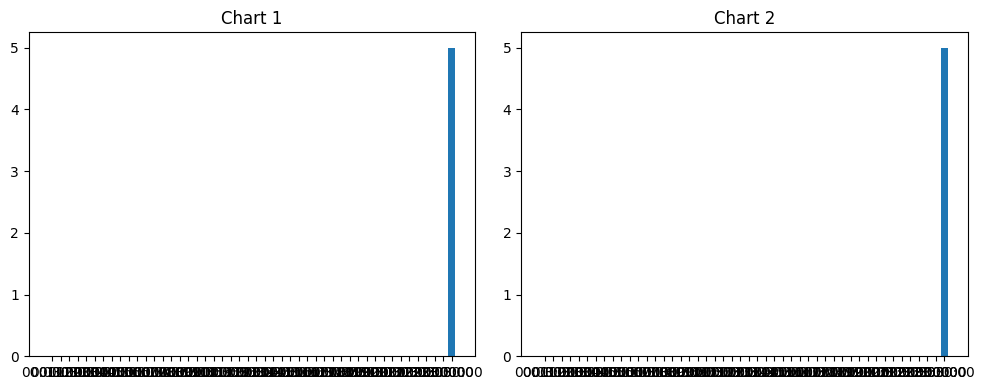

In [43]:
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C']
values1 = [4.2, 2.5, 3.7]
values2 = [1.1, 3.3, 2.2]

categories = ['00:00:00', '00:30:00', '01:00:00', '01:30:00', '02:00:00', '02:30:00', '03:00:00', '03:30:00', '04:00:00', '04:30:00', '05:00:00', '05:30:00', '06:00:00', '06:30:00', '07:00:00', '07:30:00', '08:00:00', '08:30:00', '09:00:00', '09:30:00', '10:00:00', '10:30:00', '11:00:00', '11:30:00', '12:00:00', '12:30:00', '13:00:00', '13:30:00', '14:00:00', '14:30:00', '15:00:00', '15:30:00', '16:00:00', '16:30:00', '17:00:00', '17:30:00', '18:00:00', '18:30:00', '19:00:00', '19:30:00', '20:00:00', '20:30:00', '21:00:00', '21:30:00', '22:00:00', '22:30:00', '23:00:00', '23:30:00']
values1 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5]
values2 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5]


# Create 1 row, 2 columns of subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot first bar chart
axs[0].bar(categories, values1)
axs[0].set_title('Chart 1')

# Plot second bar chart
axs[1].bar(categories, values2)
axs[1].set_title('Chart 2')

plt.tight_layout()
plt.show()

In [ ]:
   for v in visits:
        day = v.Start.date()
        if day not in days:
            days[day] = []
        days[day].append(v.Start.time().strftime('%H:%M:%S'))

In [88]:
data_folder = "./data"                               # Ask the user to select the folder containing the data
individual_files = glob.glob(data_folder + "/*.txt")
print(individual_files)

['./data/input\\data_unwrapped_animal_2.txt', './data/input\\data_unwrapped_animal_11.txt', './data/input\\data_unwrapped_animal_10.txt', './data/input\\data_unwrapped_animal_3.txt', './data/input\\data_unwrapped_animal_1.txt', './data/input\\data_unwrapped_animal_12.txt', './data/input\\data_unwrapped_animal_13.txt', './data/input\\data_unwrapped_animal_4.txt', './data/input\\data_unwrapped_animal_17.txt', './data/input\\data_unwrapped_animal_16.txt', './data/input\\data_unwrapped_animal_5.txt', './data/input\\data_unwrapped_animal_7.txt', './data/input\\data_unwrapped_animal_14.txt', './data/input\\data_unwrapped_animal_15.txt', './data/input\\data_unwrapped_animal_6.txt', './data/input\\data_unwrapped_animal_18.txt', './data/input\\data_unwrapped_animal_24.txt', './data/input\\data_unwrapped_animal_19.txt', './data/input\\data_unwrapped_animal_8.txt', './data/input\\data_unwrapped_animal_9.txt', './data/input\\data_unwrapped_animal_22.txt', './data/input\\data_unwrapped_animal_23.tx

## TO DO
### Analyze visit duration to understand the pattern

In [3]:
ml = pm.Loader(dataFiles[0])



In [6]:
# Convert times into seconds
def time_to_seconds(time_str):
    t = datetime.strptime(time_str, "%H:%M:%S")
    return t.hour * 3600 + t.minute * 60 + t.second


def plot_activity_bins(times, bin_size=1800):
    # Convert all times to seconds
    time_in_seconds = [time_to_seconds(t) for t in times]

    # Create bins: range from the min to the max time in seconds
    min_time = min(time_in_seconds)
    max_time = max(time_in_seconds)
    bins = range(min_time - (min_time % bin_size), max_time + bin_size, bin_size)

    # Plot the histogram
    plt.hist(time_in_seconds, bins=bins, edgecolor='black')

    # Formatting the x-axis to show time
    plt.xticks([min_time + bin_size * i for i in range(len(bins))],
            [str(datetime.utcfromtimestamp(b).strftime("%H:%M:%S")) for b in bins], rotation=45)

    plt.title('Histogram of Times (30-minute bins)')
    plt.xlabel('Time (HH:MM:SS)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


# Modified function to accept a list of time lists
def plot_multiple_activity_bins(animal, times, output_path, bin_size=1800, titles=None):
    """
    Plots multiple vertical histograms of activity times.
    
    Parameters:
    - times_list: List of lists of time strings (e.g., [[times1], [times2], ...])
    - bin_size: Bin size in seconds (default: 1800 = 30 minutes)
    - titles: Optional list of subplot titles
    """
    days = list(times.keys())
    num_plots = len(days)
    fig, axs = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 4 * num_plots), sharex=True)
    times_list = a = list(times.values())
    # Handle case where there's only 1 plot (axs is not a list)
    if num_plots == 1:
        axs = [axs]

    global_min_time = float('inf')
    global_max_time = float('-inf')

    # First, find global min/max across all datasets to make bins consistent
    all_seconds = []
   
    for i, times in enumerate(times_list):
        time_in_seconds = [time_to_seconds(t) for t in times]
        all_seconds.append(time_in_seconds)
        global_min_time = min(global_min_time, min(time_in_seconds))
        global_max_time = max(global_max_time, max(time_in_seconds))
       

    # Define common bin edges
    bin_start = global_min_time - (global_min_time % bin_size)
    bin_end = global_max_time + bin_size
    bins = range(bin_start, bin_end, bin_size)
    xtick_labels = [str(datetime.utcfromtimestamp(b).strftime("%H:%M:%S")) for b in bins]

    # Plot each dataset
    for i, time_in_seconds in enumerate(all_seconds):
        axs[i].hist(time_in_seconds, bins=bins, edgecolor='black')
        axs[i].set_ylabel("Frequency")
        axs[i].set_title(titles[i] if titles and i < len(titles) else f"{animal} - {days[i]}")
        axs[i].set_xticks(bins)
        axs[i].set_xticklabels(xtick_labels, rotation=45)

    # Set common x-axis ticks
  

    
    #axs[-1].set_xlabel("Time (HH:MM:SS)")
    plt.tight_layout()
    #plt.subplots_adjust(hspace=0.5)  # Increase this value to add more space
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

bin_size=1800


frozenset({'Animal 23', 'Animal 14', 'Animal 24', 'Animal 15', 'Animal 17', 'Animal 9', 'Animal 21', 'Animal 13', 'Animal 4', 'Animal 6', 'Animal 3', 'Animal 11', 'Animal 20', 'Animal 7', 'Animal 12', 'Animal 22', 'Animal 19', 'Animal 8', 'Animal 5', 'Animal 1', 'Animal 10', 'Animal 16', 'Animal 18', 'Animal 2'})
Animal 23
Animal 14
Animal 24
Animal 15
Animal 17
Animal 9
Animal 21
Animal 13
Animal 4
Animal 6
Animal 3
Animal 11
Animal 20
Animal 7
Animal 12
Animal 22
Animal 19
Animal 8
Animal 5


KeyboardInterrupt: 

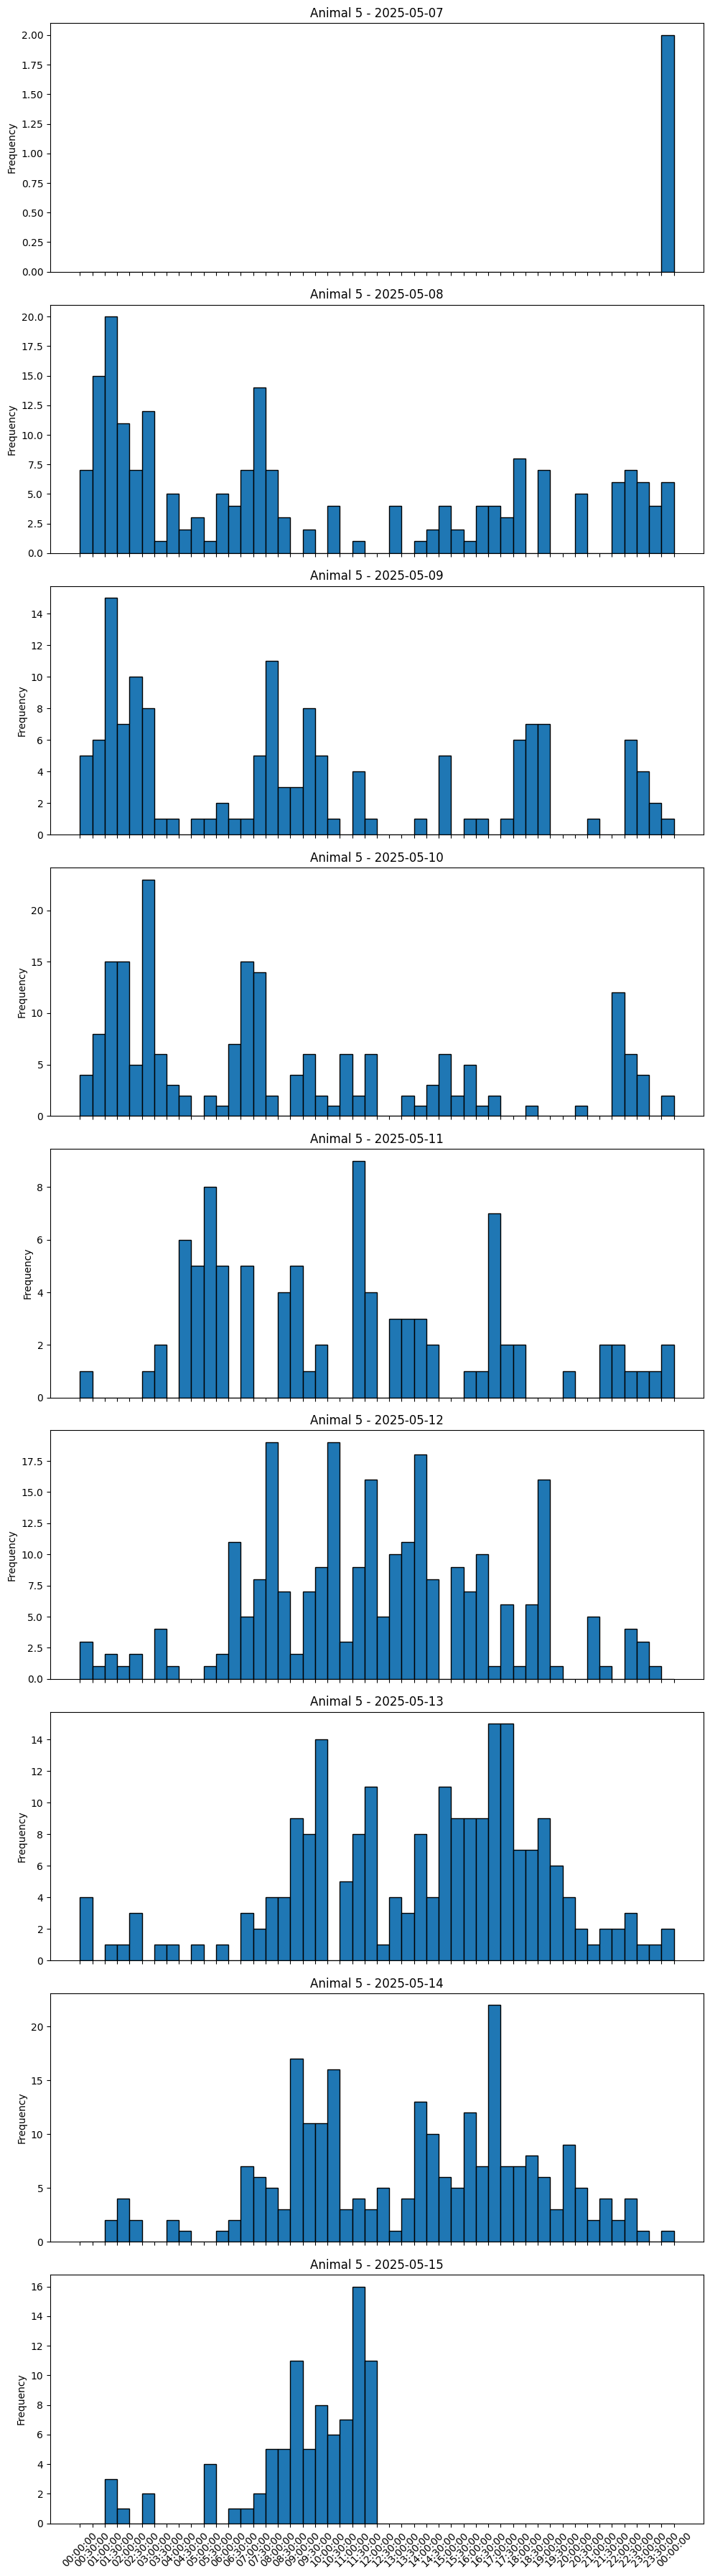

In [7]:
output_folder = "result"
os.makedirs(output_folder, exist_ok=True)

animals = ml.getAnimal()
animals_str = list(ml.getAnimal())
print(animals)
for animal in animals:
    result_folder = f"{output_folder}/{animal}"
    #animals[animal]['save_folder'] = result_folder
    os.makedirs(result_folder, exist_ok=True)
    print(animal)
    visits = ml.getVisits(mice=animal, order='Start')
    days = {}

    for v in visits:
        day = v.Start.date()
        if day not in days:
            days[day] = []
        days[day].append(v.Start.time().strftime('%H:%M:%S'))

    plot_folder = f"{result_folder}/plot"
    os.makedirs(plot_folder, exist_ok=True)

    output_path = f"{plot_folder}/{animal}.png"
    plot_multiple_activity_bins(animal, days, output_path, bin_size=1800, titles=None)

    #chp.actogram_bar(animals[animal]['protocol'], first_hour = 18, save_folder = animals[animal]['save_folder'], save_suffix = 'bar', adjust_figure = [2, 0.85, 0.85, 0.2, 0.15], format = format, x_label = 'TIME (HOUR)', ticks_fontsize=[11,11], )
    #chp.actogram_colormap(animals[animal]['protocol'], first_hour = 18, save_folder = animals[animal]['save_folder'], save_suffix = 'colormap', adjust_figure = [2, 0.85, 0.85, 0.2, 0.15], format = format, norm_color = None, x_label = 'TIME (HOUR)', ticks_fontsize=[11,11], unit_of_measurement='VISITS')
    #chp.data_periodogram(animals[animal]['protocol'], time_shape = 'continuous', method = 'periodogram', max_period = 48, unit_of_measurement = 'VISITS', save_folder = animals[animal]['save_folder'], save_suffix = 'periodogram', format = format, ticks_fontsize=[14,14], labels_fontsize=[14,16,16])
    #chp.data_periodogram(animals[animal]['protocol'], time_shape = 'continuous', method = 'welch', max_period = 48, unit_of_measurement = 'VISITS', save_folder = animals[animal]['save_folder'], save_suffix = 'welch', format = format, ticks_fontsize=[14,14], labels_fontsize=[14,16,16])

    #print(animal.replace('_', ' ').capitalize() + ' actograms saved!')
 

In [ ]:
for count, key in enumerate(list(animals.keys())):
    animals[key]['save_folder'] = result_folder + '\\' + key
    if key not in os.listdir(result_folder):
        os.makedirs(result_folder + '\\' + key, exist_ok=True)
        print("Folder " + key + " created!")
    elif key in os.listdir(result_folder) and reset == True:
        reset_folder(result_folder + '\\' + key)
        print("Folder " + key + " cleaned!")
    else:
        print("Folder " + key + " already exists!")

In [ ]:
format = 'svg'
for animal in animals:
    chp.actogram_bar(animals[animal]['protocol'], first_hour = 18, save_folder = animals[animal]['save_folder'], save_suffix = 'bar', adjust_figure = [2, 0.85, 0.85, 0.2, 0.15], format = format, x_label = 'TIME (HOUR)', ticks_fontsize=[11,11], )
    chp.actogram_colormap(animals[animal]['protocol'], first_hour = 18, save_folder = animals[animal]['save_folder'], save_suffix = 'colormap', adjust_figure = [2, 0.85, 0.85, 0.2, 0.15], format = format, norm_color = None, x_label = 'TIME (HOUR)', ticks_fontsize=[11,11], unit_of_measurement='VISITS')
    chp.data_periodogram(animals[animal]['protocol'], time_shape = 'continuous', method = 'periodogram', max_period = 48, unit_of_measurement = 'VISITS', save_folder = animals[animal]['save_folder'], save_suffix = 'periodogram', format = format, ticks_fontsize=[14,14], labels_fontsize=[14,16,16])
    chp.data_periodogram(animals[animal]['protocol'], time_shape = 'continuous', method = 'welch', max_period = 48, unit_of_measurement = 'VISITS', save_folder = animals[animal]['save_folder'], save_suffix = 'welch', format = format, ticks_fontsize=[14,14], labels_fontsize=[14,16,16])

    print(animal.replace('_', ' ').capitalize() + ' actograms saved!')

In [79]:
from datetime import datetime, time, timedelta

def get_zeitgeber_time(clock_dt, zt0_time):
    """
    Convert clock time to Zeitgeber Time (ZT), supporting timezone-aware datetimes.

    :param clock_dt: datetime with or without timezone
    :param zt0_time: time object (assumed to be in the same timezone as clock_dt)
    :return: Zeitgeber Time as float (0 <= ZT < 24)
    """
    # Use the timezone from the input datetime, if available
    tzinfo = clock_dt.tzinfo
    zt0_dt = datetime.combine(clock_dt.date(), zt0_time, tzinfo=tzinfo)

    # Adjust ZT0 to the previous day if clock time is earlier
    if clock_dt < zt0_dt:
        zt0_dt -= timedelta(days=1)

    # Time difference in hours
    delta = clock_dt - zt0_dt
    zt_hours = delta.total_seconds() / 3600

    return round(zt_hours % 24, 2)


# ZT0 at 0:00 (local time assumed to match clock_time's timezone)
zt0 = time(0, 0)


visits = ml.getVisits(mice='C57 A 1')
# print(len(visits))
# print(visits[321].Animal)
# print(visits[321].Corner)
# print(visits[321].Cage)
print(visits[321].Start)
zt = get_zeitgeber_time(visits[321].Start, zt0)
print(f"ZT: {zt}")  # Should print something like ZT: 4.08
# print(visits[321].End)

IndexError: list index out of range

In [ ]:
visits = ml.getVisits(order='Animal.Name')
for visit in visits[::500]:
    print(visit.Animal.Name)

C57 A 1
C57 A 10
C57 A 11
C57 A 2
C57 A 3
C57 A 4
C57 A 6
C57 A 8
C57 A 9
C57 B 1
C57 B 10
C57 B 12
C57 B 2
C57 B 4
C57 B 5
C57 B 9


In [ ]:
#It is possible to have visits ordered firstly by one attibute, then by another one (and so on) by passing a sequence of attribute names as order parameter.



visits = ml.getVisits(order=('Cage', 'Corner'))
for visit in visits[::500]:
    print('Animal %s - cage %d - corner %d / duration %s - %s' % (visit.Animal.Name, visit.Cage, visit.Corner, str(visit.Start), str(visit.End)))

Animal C57 B 11 - cage 1 - corner 1 / duration 2012-08-28 15:38:30.937000+02:00 - 2012-08-28 15:39:21.171000+02:00
Animal C57 B 11 - cage 1 - corner 1 / duration 2012-08-30 22:07:43.562000+02:00 - 2012-08-30 22:07:45.781000+02:00
Animal C57 B 12 - cage 1 - corner 2 / duration 2012-08-29 21:35:48.015000+02:00 - 2012-08-29 21:35:49.437000+02:00
Animal C57 B 1 - cage 1 - corner 3 / duration 2012-08-28 18:44:40.843000+02:00 - 2012-08-28 18:45:02.125000+02:00
Animal C57 B 3 - cage 1 - corner 3 / duration 2012-08-30 08:42:15.609000+02:00 - 2012-08-30 08:42:31.625000+02:00
Animal C57 B 12 - cage 1 - corner 4 / duration 2012-08-28 21:59:14.921000+02:00 - 2012-08-28 21:59:37.421000+02:00
Animal C57 B 6 - cage 1 - corner 4 / duration 2012-08-30 19:57:50.437000+02:00 - 2012-08-30 20:00:06.343000+02:00
Animal C57 A 1 - cage 2 - corner 1 / duration 2012-08-29 15:58:56.281000+02:00 - 2012-08-29 15:59:03.375000+02:00
Animal C57 A 4 - cage 2 - corner 2 / duration 2012-08-28 15:48:59.484000+02:00 - 201

Visits of a particular mouse
It is common to analyse visits of cetrain animal.

To select visits of a particular mouse pass its name as the mice parameter of .getVisits() method.

In [ ]:
visits = ml.getVisits(mice='C57 A 1')
print(len(visits))
print(visits[321].Animal)

493
C57 A 1


### Visits of a group of mice
The mice parameter accepts also multiple names.

In [ ]:
visits = ml.getVisits(mice=['C57 A 1', 'C57 A 2'])
visitorNames = [v.Animal.Name for v in visits]
for mouse in set(visitorNames):
    print('%s: %d visits' % (mouse, visitorNames.count(mouse)))

C57 A 1: 493 visits
C57 A 2: 281 visits


### Visits performed at particular time
Analyses are very often focused on a certain time period (e.g. phase of experiment phase).

To select visits before or after particular time you can use (respectively) start and end parameters of getVisits() method.

In the example visits started between 15:00 (inclusive) and 16:00 (exclusive) 28th August 2012 are being selected. The time is given as Eastern European Time (EET).

In [ ]:
from datetime import datetime
import pytz

EET = pytz.timezone('Etc/GMT-2')

timeFrom = datetime(2012, 8, 28, 15, 0, tzinfo=EET)
timeTo = datetime(2012, 8, 28, 16, 0, tzinfo=EET)

visits = ml.getVisits(start=timeFrom, end=timeTo)
print(min(v.Start for v in visits))
print(max(v.Start for v in visits))

2012-08-28 15:34:14.140000+02:00
2012-08-28 15:59:48.546000+02:00


### Loading a configuration file
To load a configuration file pass a path to it to the class constructor. Then you will be able to list defined time period (with .sections() method) and get their boundaries (with .getTime() method).

In [ ]:
timeline = pm.Timeline('C57_AB/timeline.ini')

for timePeriod in timeline.sections():
    start, end = timeline.getTimeBounds(timePeriod)
    print("%s:\t%s - %s" % (timePeriod, start, end))

SA 1 dark:	2012-08-28 13:00:00+02:00 - 2012-08-29 01:00:00+02:00
SA 1 light:	2012-08-29 01:00:00+02:00 - 2012-08-29 13:00:00+02:00
SA 2 dark:	2012-08-29 13:00:00+02:00 - 2012-08-30 01:00:00+02:00
SA 2 light:	2012-08-30 01:00:00+02:00 - 2012-08-30 13:00:00+02:00
SA 3 dark:	2012-08-30 13:00:00+02:00 - 2012-08-31 01:00:00+02:00
SA 3 light:	2012-08-31 01:00:00+02:00 - 2012-08-31 13:00:00+02:00
SA 4 dark:	2012-08-31 13:00:00+02:00 - 2012-09-01 01:00:00+02:00
SA 4 light:	2012-09-01 01:00:00+02:00 - 2012-09-01 13:00:00+02:00
SA 5 dark:	2012-09-01 13:00:00+02:00 - 2012-09-02 01:00:00+02:00
SA 5 light:	2012-09-02 01:00:00+02:00 - 2012-09-02 13:00:00+02:00
NPA 1 dark:	2012-09-02 13:00:00+02:00 - 2012-09-03 01:00:00+02:00
NPA 1 light:	2012-09-03 01:00:00+02:00 - 2012-09-03 13:00:00+02:00
NPA 2 dark:	2012-09-03 13:00:00+02:00 - 2012-09-04 01:00:00+02:00
NPA 2 light:	2012-09-04 01:00:00+02:00 - 2012-09-04 13:00:00+02:00
Place Pref 1 dark:	2012-09-04 13:00:00+02:00 - 2012-09-05 01:00:00+02:00
Place 

### Boundaries of many time periods
To get boundaries of a minimal time period covering several time periods defined in the config file pass a collection of their names as a parameter of .getTime() method.

In [ ]:
start, end = timeline.getTimeBounds(['Place Pref 1 dark',
                                     'Place Pref 3 light'])
print('%s - %s' % (start, end))

2012-09-04 13:00:00+02:00 - 2012-09-07 13:00:00+02:00


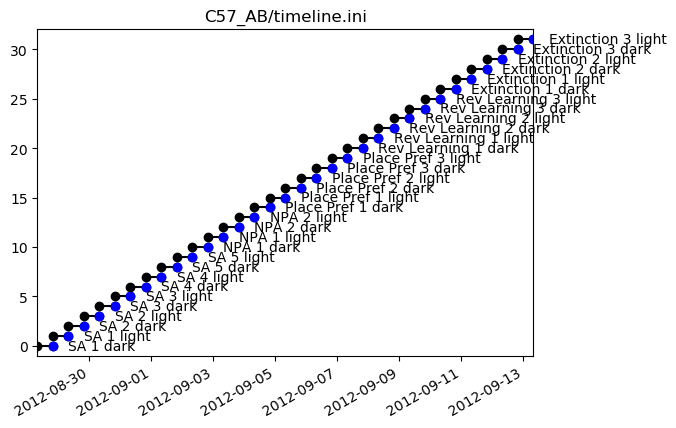

In [ ]:
%matplotlib inline

import pymice.debug as pmd
_ = pmd.plotPhases(timeline)

In [ ]:
ml = pm.Loader('C57_AB/2012-08-28 15.33.58.zip', getNp=False)
visits = ml.getVisits(order=('Start', 'End'))
visit = visits[4]
print(visit.Nosepokes)

None


In [ ]:
print(ml.getLog())
print(ml.getEnvironment())
print(ml.getHardwareEvents())
ml = pm.Loader('C57_AB/2012-08-28 15.33.58.zip', getLog=True, getHw=True, getEnv=True, getNp=True)
print(len(ml.getLog()))
print(len(ml.getEnvironment()))
print(len(ml.getHardwareEvents()))

for v in ml.getVisits(order='Start'):
    print('%s %d %s' % (str(v.Animal), len(v.Nosepokes), list(v.Animal.Tag)[0]))

[< Log Info, Application (at 2012-08-28 15:34:00.093) >, < Log Warning, Lickometer (at 2012-08-28 15:34:54.671) >, < Log Warning, Lickometer (at 2012-08-28 15:34:54.984) >, < Log Warning, Lickometer (at 2012-08-28 15:34:55.953) >, < Log Warning, Lickometer (at 2012-08-28 15:35:03.000) >, < Log Warning, Lickometer (at 2012-08-28 15:36:36.656) >, < Log Warning, Lickometer (at 2012-08-28 15:36:37.296) >, < Log Warning, Lickometer (at 2012-08-28 15:39:56.968) >, < Log Warning, Lickometer (at 2012-08-28 15:42:49.218) >, < Log Warning, Lickometer (at 2012-08-28 15:51:42.890) >, < Log Warning, Lickometer (at 2012-08-28 15:54:16.375) >, < Log Warning, Lickometer (at 2012-08-28 15:54:21.531) >, < Log Warning, Lickometer (at 2012-08-28 15:54:23.000) >, < Log Warning, Lickometer (at 2012-08-28 15:54:41.671) >, < Log Warning, Lickometer (at 2012-08-28 16:03:32.984) >, < Log Warning, Lickometer (at 2012-08-28 16:04:05.156) >, < Log Warning, Lickometer (at 2012-08-28 16:06:01.375) >, < Log Warning, 

In [ ]:
loaders = [pm.Loader(filename, getLog=True) for filename in dataFiles]
mm = pm.Merger(*loaders, getLog=True)

dataValidator = pm.DataValidator(pm.LickometerLogAnalyzer(),
                                 pm.PresenceLogAnalyzer())
validatorReport = dataValidator(mm)

/opt/miniconda3/lib/python3.8/site-packages/pymice/LogAnalyser.py:141: MatplotlibDeprecationWarning: Moved to matplotlib.cbook
  idcs = mmlab.contiguous_regions(medHist > self.medThreshold)


In [ ]:
start = mm.getStart()
end = mm.getEnd()
interval = (start, end)

strInterval = '(from %s to %s)' % interval

noLickometerProblems = pm.FailureInspector('Lickometer')
noPresenceProblems = pm.FailureInspector('Presence')

if noLickometerProblems(validatorReport, interval):
    print("lickometer ok " + strInterval)

else:
    print("lickometer problem " + strInterval)

if noPresenceProblems(validatorReport, interval):
    print("presences ok " + strInterval)

else:
    print("unknown mice presence problem " + strInterval)

lickometer problem (from 2012-08-28 13:44:52.671000+02:00 to 2012-09-13 13:35:34.390000+02:00)
presences ok (from 2012-08-28 13:44:52.671000+02:00 to 2012-09-13 13:35:34.390000+02:00)


In [ ]:
#https://neuroinflab.github.io/PyMICE/manual.html#module-pymice